<a href="https://colab.research.google.com/github/Nadiaesterlianasiahaa/P2_ResNet18/blob/main/P2_Persiapan_DataResNet_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Nadia Esterliana Siahaan
Nim  : 4222401001


# P2: Pelatihan ResNet-18

**RET503 · Pertemuan 3 · Transfer Learning — huruf_angka vs panah**

## Latar belakang

Notebook ini melatih ResNet-18 untuk klasifikasi rambu pada robot Smorphi. Data sudah diubah dari dataset *object detection* Roboflow (`image-detection-qixfs`, versi 9, CC BY 4.0) menjadi label tingkat gambar dengan dua kelas: **huruf_angka** dan **panah**.

Tugas P2 membandingkan tiga strategi transfer learning (feature extraction, fine-tuning parsial, scratch) lalu mengukur latensi terhadap anggaran 15 FPS.

## Keputusan desain

| Pilihan | Nilai | Alasan |
|---------|-------|--------|
| Model | ResNet-18 | Model praktikum; trade-off akurat vs komputasi |
| Strategi | feature → partial → scratch | Sesuai slide 8 & 23 |
| Input | Frame utuh 224×224 | Robot menerima frame penuh, bukan crop |
| Preprocessing | mean/std ImageNet | Harus identik dengan model sumber (slide 13) |
| Split | Dari kolom `split` di metadata | Sudah dipisah per sesi (anti leakage) |
| LR feature/scratch | 1e-3 | Standar head baru |
| LR partial | layer4 1e-4, fc 1e-3 | Discriminative LR (slide 12) |

## Hipotesis

Feature extraction dan fine-tuning parsial diharapkan jauh lebih baik daripada scratch pada data train ~200 citra.

1. SetUP

In [ ]:
# P2 Notebook B — Train ResNet-18 (huruf_angka vs panah)
# RET503 · Pertemuan 3 · Transfer Learning


import os, random, time, shutil, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights, MobileNet_V3_Small_Weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

WORK = Path("/content/p2")
RESULTS = WORK / "results"
DATASET_SPLIT = WORK / "dataset_split"
for d in (WORK, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

# --- Upload dataset_raw (1).zip ---
from google.colab import files
print("Upload file: dataset_raw (1).zip")
uploaded = files.upload()

for name in uploaded:
    if name.endswith(".zip"):
        extract_to = WORK / "dataset_raw"
        if extract_to.exists():
            shutil.rmtree(extract_to)
        extract_to.mkdir(parents=True)
        with zipfile.ZipFile(name) as z:
            z.extractall(extract_to)
        print(f"Diekstrak: {name}")

# Cari metadata.csv (antisipasi struktur folder berlapis)
found = list(WORK.rglob("metadata.csv"))
assert found, "metadata.csv tidak ditemukan. Cek ZIP."
DATASET_RAW = found[0].parent
print(f"DATASET_RAW = {DATASET_RAW}")

meta = pd.read_csv(DATASET_RAW / "metadata.csv")
print(f"\nTotal citra: {len(meta)}")
print(meta["kelas"].value_counts().to_string())
print("\nSplit:")
print(pd.crosstab(meta["kelas"], meta["split"]))

Device: cpu
Upload file: dataset_raw (1).zip


Saving dataset_raw (1).zip to dataset_raw (1) (1).zip
Diekstrak: dataset_raw (1) (1).zip
DATASET_RAW = /content/p2/dataset_raw

Total citra: 359
kelas
huruf_angka    180
panah          179

Split:
split        test  train  val
kelas                        
huruf_angka    51    100   29
panah          32     95   52


## 2. Bentuk folder train / val

Pembagian **tidak diacak ulang**. Kolom `split` di metadata sudah hasil pemisahan per `session_id` (StratifiedGroupKFold).

Frame beruntun dari posisi hampir sama cenderung sangat mirip. Jika frame semacam itu masuk train dan val sekaligus, akurasi validasi menjadi terlalu optimistis (data leakage, slide 24).

| Split | Dipakai untuk |
|-------|----------------|
| train | Pelatihan |
| val   | Pilih model & early insight |
| test  | Disisihkan (evaluasi akhir, opsional) |

In [ ]:
if DATASET_SPLIT.exists():
    shutil.rmtree(DATASET_SPLIT)

for split in ["train", "val"]:
    for cls in ["huruf_angka", "panah"]:
        (DATASET_SPLIT / split / cls).mkdir(parents=True)

counts = {"train": 0, "val": 0}
missing = 0
for _, row in meta.iterrows():
    if row["split"] not in ("train", "val"):
        continue  # test disimpan terpisah
    src = DATASET_RAW / row["kelas"] / row["nama_file"]
    dst = DATASET_SPLIT / row["split"] / row["kelas"] / row["nama_file"]
    if not src.exists():
        print(f"[WARN] hilang: {src}")
        missing += 1
        continue
    shutil.copy2(src, dst)
    counts[row["split"]] += 1

print(f"Train: {counts['train']} | Val: {counts['val']} | Missing: {missing}")
for split in ["train", "val"]:
    for cls in ["huruf_angka", "panah"]:
        n = len(list((DATASET_SPLIT / split / cls).glob("*")))
        print(f"  {split}/{cls}: {n}")

Train: 195 | Val: 81 | Missing: 0
  train/huruf_angka: 100
  train/panah: 95
  val/huruf_angka: 29
  val/panah: 52


## 3. Preprocessing dan DataLoader

Preprocessing **harus identik** dengan model ImageNet (slide 13):

| Parameter | Nilai |
|-----------|--------|
| Ukuran input | 224×224 |
| mean | 0,485 · 0,456 · 0,406 |
| std | 0,229 · 0,224 · 0,225 |

Augmentasi hanya pada train: `RandomResizedCrop`, `HorizontalFlip`, `ColorJitter`.  
Validasi memakai `CenterCrop` tanpa acak agar metrik stabil.

In [ ]:
NUM_CLASSES = 2
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR_HEAD = 1e-3
LR_LAYER4 = 1e-4
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
MODES = ["feature", "partial", "scratch"]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(DATASET_SPLIT / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DATASET_SPLIT / "val",   transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Kelas ImageFolder: {train_ds.classes}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Kelas ImageFolder: ['huruf_angka', 'panah']
Train: 195 | Val: 81


## 4. Tiga mode transfer learning

| Mode | Bobot awal | Yang dilatih | Learning rate |
|------|------------|--------------|---------------|
| **feature** | ImageNet | fc saja | 1e-3 |
| **partial** | ImageNet | layer4 + fc | 1e-4 / 1e-3 |
| **scratch** | acak | semua | 1e-3 |

**Feature extraction** — backbone beku, hanya classifier baru dilatih. Cocok bila data sedikit dan domain mirip.

**Fine-tuning parsial** — buka blok akhir (layer4) + head, dengan discriminative LR agar fitur umum tidak rusak.

**Scratch** — baseline dari bobot acak; diharapkan lebih buruk pada data kecil.

In [ ]:
def build_model(mode: str):
    if mode == "scratch":
        model = models.resnet18(weights=None)
    else:
        model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    if mode == "feature":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "partial":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    return model.to(DEVICE)


def get_optimizer(model, mode: str):
    if mode == "partial":
        return torch.optim.Adam([
            {"params": model.layer4.parameters(), "lr": LR_LAYER4},
            {"params": model.fc.parameters(),     "lr": LR_HEAD},
        ])
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=LR_HEAD)

## 5. Pelatihan

Yang dicatat tiap mode (slide 23):

- Akurasi validasi terbaik  
- Waktu pelatihan  
- Epoch saat akurasi ≥ 90%

Scheduler: `CosineAnnealingLR`.  
Checkpoint terbaik disimpan di `results/best_{mode}.pth`.

In [13]:
def train_one_mode(mode: str):
    print(f"\n{'='*60}")
    print(f" MODE: {mode.upper()}")
    print(f"{'='*60}")

    model = build_model(mode)
    optimizer = get_optimizer(model, mode)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val, epoch_90 = 0.0, None
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        # ---- TRAIN ----
        if mode == "feature":
            model.eval()
            model.fc.train()
        else:
            model.train()

        run_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_loss = run_loss / total
        train_acc  = correct / total

        # ---- VAL ----
        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                loss = criterion(out, y)
                run_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_loss = run_loss / total
        val_acc  = correct / total
        scheduler.step()

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), RESULTS / f"best_{mode}.pth")
        if epoch_90 is None and val_acc >= 0.90:
            epoch_90 = epoch

        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"train={train_acc:.3f} val={val_acc:.3f} | "
              f"loss={train_loss:.4f}/{val_loss:.4f}")

    elapsed = time.time() - t0
    print(f"\n[HASIL {mode.upper()}]")
    print(f"  Best val acc : {best_val:.4f}")
    print(f"  Waktu        : {elapsed:.1f} s")
    print(f"  Epoch ≥ 90%  : {epoch_90 or 'tidak tercapai'}")

    # Grafik
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(history["train_acc"], label="train")
    ax[0].plot(history["val_acc"], label="val")
    ax[0].set_title(f"Accuracy – {mode}")
    ax[0].legend(); ax[0].grid(True)
    ax[1].plot(history["train_loss"], label="train")
    ax[1].plot(history["val_loss"], label="val")
    ax[1].set_title(f"Loss – {mode}")
    ax[1].legend(); ax[1].grid(True)
    plt.tight_layout()
    plt.savefig(RESULTS / f"curve_{mode}.png", dpi=120)
    plt.show()

    return {
        "mode": mode,
        "best_val_acc": best_val,
        "time_sec": elapsed,
        "epoch_90": epoch_90,
    }


 MODE: FEATURE
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 42.8MB/s]


Epoch 01/10 | train=0.554 val=0.679 | loss=0.6818/0.6499
Epoch 02/10 | train=0.656 val=0.716 | loss=0.6216/0.6255
Epoch 03/10 | train=0.703 val=0.778 | loss=0.5763/0.5084
Epoch 04/10 | train=0.703 val=0.840 | loss=0.5469/0.4900
Epoch 05/10 | train=0.764 val=0.889 | loss=0.5019/0.4641
Epoch 06/10 | train=0.744 val=0.901 | loss=0.4998/0.4578
Epoch 07/10 | train=0.800 val=0.914 | loss=0.5023/0.4523
Epoch 08/10 | train=0.810 val=0.815 | loss=0.4926/0.4401
Epoch 09/10 | train=0.764 val=0.901 | loss=0.4927/0.4413
Epoch 10/10 | train=0.805 val=0.914 | loss=0.4798/0.4423

[HASIL FEATURE]
  Best val acc : 0.9136
  Waktu        : 234.0 s
  Epoch ≥ 90%  : 6


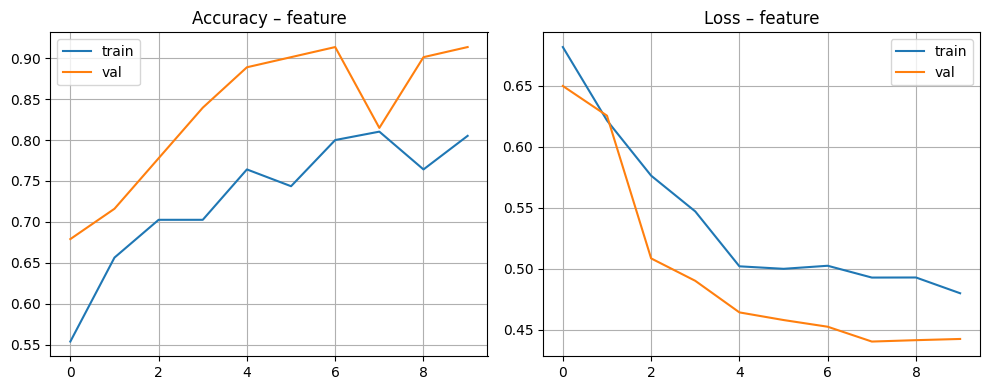


 MODE: PARTIAL
Epoch 01/10 | train=0.610 val=0.926 | loss=0.6302/0.2799
Epoch 02/10 | train=0.836 val=0.963 | loss=0.3460/0.1585
Epoch 03/10 | train=0.867 val=0.951 | loss=0.3298/0.1214
Epoch 04/10 | train=0.851 val=0.988 | loss=0.3027/0.0554
Epoch 05/10 | train=0.892 val=0.951 | loss=0.2395/0.1204
Epoch 06/10 | train=0.908 val=0.963 | loss=0.2543/0.0982
Epoch 07/10 | train=0.872 val=0.963 | loss=0.2768/0.0921
Epoch 08/10 | train=0.918 val=0.963 | loss=0.1994/0.0782
Epoch 09/10 | train=0.918 val=0.938 | loss=0.2033/0.1559
Epoch 10/10 | train=0.887 val=0.938 | loss=0.2474/0.1431

[HASIL PARTIAL]
  Best val acc : 0.9877
  Waktu        : 316.5 s
  Epoch ≥ 90%  : 1


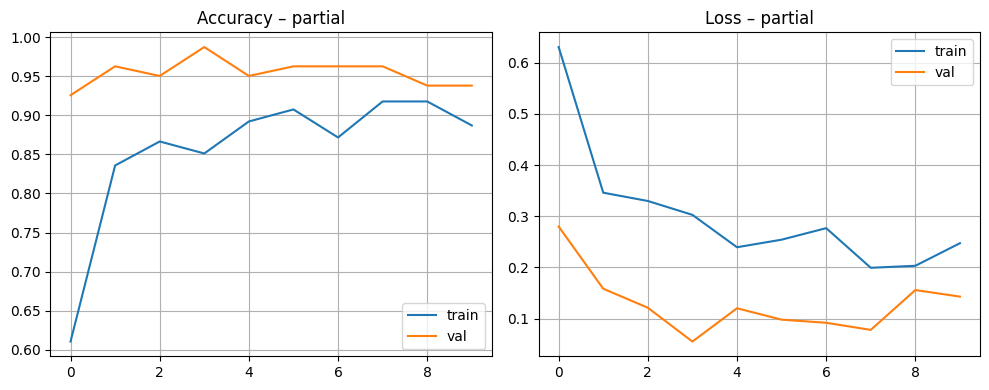


 MODE: SCRATCH
Epoch 01/10 | train=0.513 val=0.333 | loss=1.0811/0.7819
Epoch 02/10 | train=0.585 val=0.568 | loss=0.7118/0.7398
Epoch 03/10 | train=0.533 val=0.556 | loss=0.7067/0.6811
Epoch 04/10 | train=0.585 val=0.506 | loss=0.6758/0.6310
Epoch 05/10 | train=0.559 val=0.506 | loss=0.6881/0.6824
Epoch 06/10 | train=0.564 val=0.679 | loss=0.6816/0.6263
Epoch 07/10 | train=0.656 val=0.667 | loss=0.6322/0.6233
Epoch 08/10 | train=0.667 val=0.531 | loss=0.6008/0.6778
Epoch 09/10 | train=0.656 val=0.519 | loss=0.5901/0.6188
Epoch 10/10 | train=0.626 val=0.531 | loss=0.5726/0.6122

[HASIL SCRATCH]
  Best val acc : 0.6790
  Waktu        : 537.2 s
  Epoch ≥ 90%  : tidak tercapai


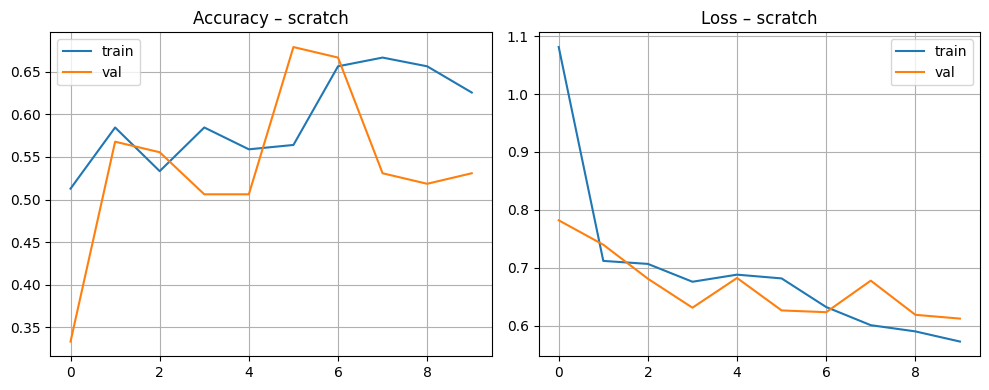


Mode         Best Val Acc  Waktu (s)   Epoch ≥90%
--------------------------------------------------
feature            0.9136      234.0            6
partial            0.9877      316.5            1
scratch            0.6790      537.2            -

Tabel disimpan: /content/p2/results/tabel_hasil.md


In [ ]:
results = []
for m in MODES:
    results.append(train_one_mode(m))

print("\n" + "="*55)
print(f"{'Mode':<12} {'Best Val Acc':>12} {'Waktu (s)':>10} {'Epoch ≥90%':>12}")
print("-"*50)

lines = [
    "# Tabel Hasil 3 Mode (ResNet-18)\n",
    "| Mode | Best Val Acc | Waktu (s) | Epoch ≥ 90% |",
    "|------|--------------|-----------|-------------|",
]
for r in results:
    e90 = str(r["epoch_90"]) if r["epoch_90"] else "-"
    print(f"{r['mode']:<12} {r['best_val_acc']:>12.4f} {r['time_sec']:>10.1f} {e90:>12}")
    lines.append(f"| {r['mode']} | {r['best_val_acc']:.4f} | {r['time_sec']:.1f} | {e90} |")

(RESULTS / "tabel_hasil.md").write_text("\n".join(lines) + "\n")
print(f"\nTabel disimpan: {RESULTS / 'tabel_hasil.md'}")

In [ ]:
def measure_latency(model, n_warmup=20, n_runs=100):
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(x)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)
    t = np.array(times)
    return {
        "mean_ms": float(t.mean()),
        "std_ms": float(t.std()),
        "p95_ms": float(np.percentile(t, 95)),
        "fps": 1000.0 / float(t.mean()),
    }

TARGET_MS = 1000 / 15  # 15 FPS ≈ 66.7 ms
print(f"Target pipeline: ≤ {TARGET_MS:.1f} ms (15 FPS)\n")

# ResNet-18 (pakai checkpoint terbaik partial jika ada)
m = build_model("feature")
ckpt = RESULTS / "best_partial.pth"
if not ckpt.exists():
    ckpt = RESULTS / "best_feature.pth"
if ckpt.exists():
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    print(f"Loaded: {ckpt.name}")
m.eval()
stats_r = measure_latency(m)
print(f"ResNet-18              mean={stats_r['mean_ms']:.2f} ± {stats_r['std_ms']:.2f} ms | FPS={stats_r['fps']:.1f}")

# MobileNetV3-Small (perbandingan)
m2 = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1).to(DEVICE)
m2.classifier[-1] = nn.Linear(m2.classifier[-1].in_features, NUM_CLASSES).to(DEVICE)
m2.eval()
stats_m = measure_latency(m2)
print(f"MobileNetV3-Small      mean={stats_m['mean_ms']:.2f} ± {stats_m['std_ms']:.2f} ms | FPS={stats_m['fps']:.1f}")

# Tabel anggaran
print(f"\n{'Komponen':<22} {'ms':>8}")
print("-" * 32)
budget = [
    ("Akuisisi + undistort", 5),
    ("Preprocess", 5),
    ("Inferensi (ResNet-18)", stats_r["mean_ms"]),
    ("Postprocess", 7),
    ("ROS2", 5),
    ("Margin", 10),
]
total = 0.0
for name, ms in budget:
    print(f"{name:<22} {ms:>8.1f}")
    total += ms
print("-" * 32)
print(f"{'TOTAL':<22} {total:>8.1f}  → {1000/total:.1f} FPS")
if total <= TARGET_MS:
    print("✓ MASIH DALAM ANGGARAN")
else:
    print("✗ MELEBIHI ANGGARAN — pertimbangkan MobileNet atau TensorRT")

# Simpan ringkasan latensi
lat_txt = f"""# Hasil Latensi
Device: {DEVICE}
ResNet-18: {stats_r['mean_ms']:.2f} ms ({stats_r['fps']:.1f} FPS)
MobileNetV3-Small: {stats_m['mean_ms']:.2f} ms ({stats_m['fps']:.1f} FPS)
Total pipeline (estimasi): {total:.1f} ms
"""
(RESULTS / "latency.md").write_text(lat_txt)
print(f"\nDisimpan: {RESULTS / 'latency.md'}")

Target pipeline: ≤ 66.7 ms (15 FPS)

Loaded: best_partial.pth
ResNet-18              mean=87.29 ± 17.75 ms | FPS=11.5
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 107MB/s]


MobileNetV3-Small      mean=9.70 ± 0.87 ms | FPS=103.1

Komponen                     ms
--------------------------------
Akuisisi + undistort        5.0
Preprocess                  5.0
Inferensi (ResNet-18)      87.3
Postprocess                 7.0
ROS2                        5.0
Margin                     10.0
--------------------------------
TOTAL                     119.3  → 8.4 FPS
✗ MELEBIHI ANGGARAN — pertimbangkan MobileNet atau TensorRT

Disimpan: /content/p2/results/latency.md


## 6. Pengukuran latensi

Target: **15 FPS ≈ 67 ms** untuk seluruh pipeline (slide 16), bukan hanya inferensi.

| Komponen | Estimasi |
|----------|----------|
| Akuisisi + undistort | 5 ms |
| Preprocess | 5 ms |
| Inferensi model | diukur |
| Postprocess | 7 ms |
| ROS2 | 5 ms |
| Margin | 10 ms |

ResNet-18 dibandingkan dengan MobileNetV3-Small sebagai kandidat cadangan jika latensi terlalu tinggi.

In [ ]:
shutil.make_archive(str(WORK / "hasil_p2_resnet18"), "zip", RESULTS)
print("Zip hasil:", WORK / "hasil_p2_resnet18.zip")
print("Isi:")
for f in sorted(RESULTS.iterdir()):
    print(" -", f.name)

from google.colab import files
files.download(str(WORK / "hasil_p2_resnet18.zip"))

Zip hasil: /content/p2/hasil_p2_resnet18.zip
Isi:
 - best_feature.pth
 - best_partial.pth
 - best_scratch.pth
 - curve_feature.png
 - curve_partial.png
 - curve_scratch.png
 - latency.md
 - tabel_hasil.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Analisis (isi di README)

1. Mode mana yang terbaik? Mengapa?  
2. Apakah hipotesis (feature / partial ≫ scratch) terbukti?  
3. Ada tanda leakage (val 100% di epoch awal)?  
4. Model dipilih untuk deployment + alasan (akurasi vs latensi).  
5. Risiko tersisa (tanda kecil, kelas timpang, data gelap sedikit) + mitigasi.